In [37]:
# Install Biopython (only need to run once)
!pip install biopython

# Import the libraries we will use
from Bio.Seq import Seq
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction, molecular_weight
import matplotlib.pyplot as plt

print("✅ Biopython and libraries imported successfully!")
print("You are ready for the project!")

✅ Biopython and libraries imported successfully!
You are ready for the project!


In [38]:
# Import all the libraries we need
from Bio import Entrez, SeqIO
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction
import matplotlib.pyplot as plt
from collections import Counter

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [39]:
# Set your email - NCBI requires this
Entrez.email = "alfiya.siddiqui@gmail.com"   # ← Please change to your real email address

# Download Human Insulin mRNA sequence (NM_000207.3)
handle = Entrez.efetch(db="nucleotide", id="NM_000207.3", rettype="fasta", retmode="text")
record = SeqIO.read(handle, "fasta")
handle.close()

print("✅ Sequence downloaded successfully!")
print("Sequence ID:", record.id)
print("Description:", record.description)
print("Length:", len(record.seq), "bp")
print("\nFirst 100 bases:\n", record.seq[:100])

✅ Sequence downloaded successfully!
Sequence ID: NM_000207.3
Description: NM_000207.3 Homo sapiens insulin (INS), transcript variant 1, mRNA
Length: 465 bp

First 100 bases:
 AGCCCTCCAGGACAGGCTGCATCAGAAGAGGCCATCAAGCAGATCACTGTCCTTCTGCCATGGCCCTGTGGATGCGCCTCCTGCCCCTGCTGGCGCTGCT


In [40]:
seq = record.seq

# GC Content
gc = gc_fraction(seq) * 100
print(f"GC Content: {gc:.2f}%")

# Nucleotide counts
counts = Counter(seq)
print("\nNucleotide Counts:")
for base in ['A', 'T', 'G', 'C']:
    print(f"  {base}: {counts[base]}")

# Transformations
print("\nComplement (first 60):", seq.complement()[:60])
print("Reverse Complement (first 60):", seq.reverse_complement()[:60])

# Transcription & Translation
mrna = seq.transcribe()
protein = mrna.translate(to_stop=True)

print("\nProtein Length:", len(protein), "amino acids")
print("Protein Sequence:", protein)

GC Content: 63.87%

Nucleotide Counts:
  A: 91
  T: 77
  G: 141
  C: 156

Complement (first 60): TCGGGAGGTCCTGTCCGACGTAGTCTTCTCCGGTAGTTCGTCTAGTGACAGGAAGACGGT
Reverse Complement (first 60): GCTGGTTCAAGGGCTTTATTCCATCTCTCTCGGTGCAGGAGGCGGCGGGTGTGGGGCTGC

Protein Length: 45 amino acids
Protein Sequence: SPPGQAASEEAIKQITVLLPWPCGCASCPCWRCWPSGDLTQPQPL


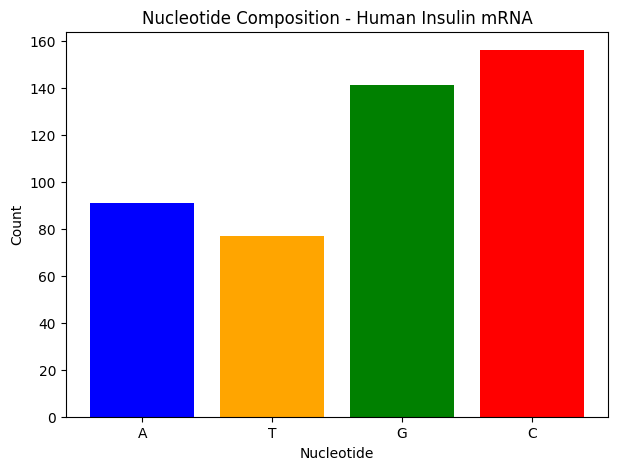

In [41]:
bases = ['A', 'T', 'G', 'C']
values = [counts[b] for b in bases]

plt.figure(figsize=(7,5))
plt.bar(bases, values, color=['blue', 'orange', 'green', 'red'])
plt.title("Nucleotide Composition - Human Insulin mRNA")
plt.xlabel("Nucleotide")
plt.ylabel("Count")
plt.show()

In [42]:
# === Extract only the Coding Sequence (CDS) ===
# For NM_000207.3, the CDS is from position 60 to 392 (1-based indexing)

cds_start = 59   # Python is 0-based, so 60-1 = 59
cds_end = 392
cds = seq[cds_start:cds_end]

print("CDS Length:", len(cds), "bp")
print("CDS starts with:", cds[:60])
print("CDS ends with:", cds[-60:])

# Translate only the CDS
protein = cds.translate(to_stop=True)
print("\nReal Insulin Preproprotein Length:", len(protein), "amino acids")
print("Protein Sequence:\n", protein)

CDS Length: 333 bp
CDS starts with: ATGGCCCTGTGGATGCGCCTCCTGCCCCTGCTGGCGCTGCTGGCCCTCTGGGGACCTGAC
CDS ends with: GTGGAACAATGCTGTACCAGCATCTGCTCCCTCTACCAGCTGGAGAACTACTGCAACTAG

Real Insulin Preproprotein Length: 110 amino acids
Protein Sequence:
 MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN


In [43]:
# Molecular Weight of the protein
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Analyze the protein
protein_analysis = ProteinAnalysis(str(protein))

mw = protein_analysis.molecular_weight()
print(f"Molecular Weight of Insulin Protein: {mw:.2f} Da")

# Amino acid composition
print("\nAmino Acid Composition:")
aa_count = protein_analysis.count_amino_acids()
for aa, count in sorted(aa_count.items()):
    if count > 0:
        print(f"  {aa}: {count}")

Molecular Weight of Insulin Protein: 11980.79 Da

Amino Acid Composition:
  A: 10
  C: 6
  D: 2
  E: 8
  F: 3
  G: 12
  H: 2
  I: 2
  K: 2
  L: 20
  M: 2
  N: 3
  P: 6
  Q: 7
  R: 5
  S: 5
  T: 3
  V: 6
  W: 2
  Y: 4


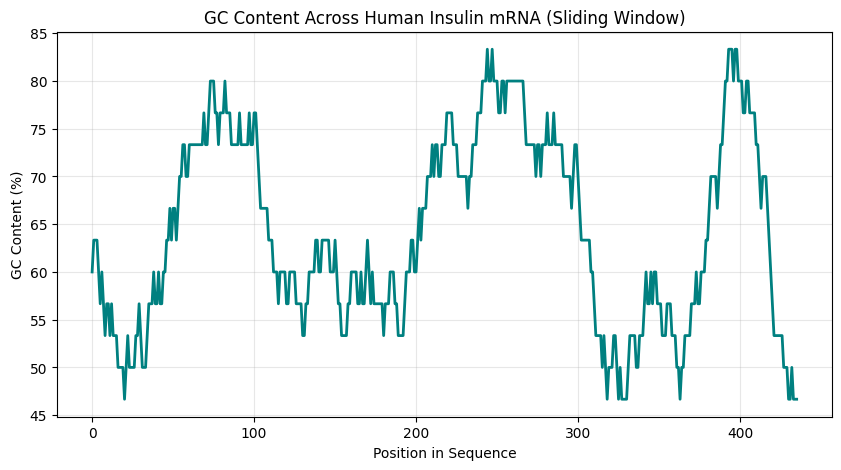

In [44]:
# Simple GC content plot (sliding window)
import numpy as np

def gc_window(seq, window_size=50):
    gc_values = []
    for i in range(len(seq) - window_size + 1):
        window = seq[i:i+window_size]
        gc_values.append(gc_fraction(window) * 100)
    return gc_values

gc_values = gc_window(seq, window_size=30)

plt.figure(figsize=(10, 5))
plt.plot(gc_values, color='teal', linewidth=2)
plt.title("GC Content Across Human Insulin mRNA (Sliding Window)")
plt.xlabel("Position in Sequence")
plt.ylabel("GC Content (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
# === Simple ORF Finder ===
def find_orfs(seq, min_length=90):
    orfs = []
    # Search in all 3 forward frames
    for frame in range(3):
        for i in range(frame, len(seq)-2, 3):
            codon = seq[i:i+3]
            if codon in ["ATG"]:  # Start codon
                # Look for stop codon
                for j in range(i+3, len(seq)-2, 3):
                    stop_codon = seq[j:j+3]
                    if stop_codon in ["TAA", "TAG", "TGA"]:
                        orf_length = j - i
                        if orf_length >= min_length:
                            orf_seq = seq[i:j+3]
                            orfs.append((frame+1, i+1, j+3, len(orf_seq), orf_seq.translate(to_stop=True)))
                        break
    return orfs

# Find ORFs in the full mRNA sequence
orfs = find_orfs(seq, min_length=90)

print("Found ORFs (minimum 90 bp):")
if orfs:
    for frame, start, end, length, prot in orfs:
        print(f"Frame {frame}: Start at {start} bp, End at {end} bp, Length: {length} bp")
        print(f"   Protein: {prot[:50]}... ({len(prot)} aa)\n")
else:
    print("No ORFs found longer than 90 bp")

Found ORFs (minimum 90 bp):
Frame 3: Start at 60 bp, End at 392 bp, Length: 333 bp
   Protein: MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY... (110 aa)

Frame 3: Start at 72 bp, End at 392 bp, Length: 321 bp
   Protein: MRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKT... (106 aa)



In [46]:
# Save results to files
with open("insulin_analysis_results.txt", "w") as f:
    f.write("=== Human Insulin Gene Analysis ===\n\n")
    f.write(f"Sequence ID: {record.id}\n")
    f.write(f"Length: {len(seq)} bp\n")
    f.write(f"GC Content: {gc_fraction(seq)*100:.2f}%\n\n")

    f.write("=== Coding Sequence (CDS) ===\n")
    f.write(f"Length: {len(cds)} bp\n")
    f.write(f"CDS: {cds}\n\n")

    f.write("=== Preproinsulin Protein ===\n")
    f.write(f"Length: {len(protein)} amino acids\n")
    f.write(f"Molecular Weight: {protein_analysis.molecular_weight():.2f} Da\n")
    f.write(f"Sequence:\n{protein}\n\n")

    f.write("=== Nucleotide Composition ===\n")
    for base in ['A','T','G','C']:
        f.write(f"{base}: {counts[base]}\n")

print("✅ Results saved to 'insulin_analysis_results.txt'")

✅ Results saved to 'insulin_analysis_results.txt'


## Biological Interpretation

The human insulin gene (INS) encodes preproinsulin, which is processed into mature insulin hormone in the beta cells of the pancreas.

### Key Findings:
- Full mRNA length: **465 bp**
- GC Content: **63.87%**
- Coding Sequence (CDS) length: **333 bp**
- Preproinsulin protein length: **110 amino acids**
- Molecular weight of the protein: **11,980.79 Da**

The protein is leucine-rich (20 residues), which is typical for many secreted proteins.

### Significance
This in silico analysis is commonly used in biotechnology before performing wet-lab experiments such as gene cloning and recombinant protein production. Understanding sequence properties helps in primer design, mutation studies, and optimizing expression systems.

# DNA Sequence Analysis of Human Insulin Gene using Biopython

**Project by:** Siddiqui Alfiya Imtiyazul Hasan  
**Program:** BSc Biotechnology  
**Date:** April 2026

## Objective
To perform basic bioinformatics analysis on the human insulin gene (INS) mRNA sequence using Biopython. This includes sequence retrieval, property calculation, translation, ORF identification, and visualization.

## Dataset
- **Accession:** NM_000207.3 (Homo sapiens insulin transcript variant 1)
- **Sequence Type:** mRNA
- **Length:** 465 bp